### acceptance functions

proportional: proposed maps are accepted with probability: $P = \min(1, \exp(\beta \cdot \Delta TCP)) $
where $\Delta TCP = TCP_{proposed} - TCP_{current}$.

- **proportional** ($\beta \in \{50, 100, 200\}$): exponential decay on bad moves. higher $\beta$ = stricter.
- **margin** (e.g. `margin_10_40`): step-function thresholds
- **simple** (e.g. `simple_25`, `simple_75`): raw tcp threshold acceptance


## Init

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import re

sns.set_theme(style='whitegrid')


In [55]:
### load and aggregate all experiment csvs
RESULTS_DIR = 'results'
TCP_COL = 'unweighted_tcp_score'
csv_files = sorted(glob.glob(f'{RESULTS_DIR}/*/*.csv'))
print(f'found {len(csv_files)} result files')
### known strategies - order matters for matching multi-token names first
STRATEGY_LIST = [
    'proportional_50', 'proportional_100', 'proportional_200',
    'margin_10_40', 'margin_20_50', 'margin_30_60',
    'simple_25', 'simple_50', 'simple_75', 'neutral',
]
CLASS_MAP = {
    'proportional': 'Proportional',
    'margin': 'Margin',
    'simple': 'Simple',
    'neutral': 'Baseline',
}
summary_rows = []
trace_frames = []  # flat list, no dict key collision
for fpath in csv_files:
    df = pd.read_csv(fpath)
    basename = os.path.basename(fpath)
    ### parse surcharges from directory name
    m = re.search(r'county_(\d+)_coi_(\d+)', fpath)
    county_surcharge = int(m.group(1)) if m else 0
    coi_surcharge = int(m.group(2)) if m else 100
    ### match strategy name
    strategy = 'unknown'
    strategy_class = 'Other'
    for s in STRATEGY_LIST:
        if s in basename:
            strategy = s
            strategy_class = CLASS_MAP[s.split('_')[0]]
            break
    ### surcharge label for plotting (e.g. "county 0 / coi 100")
    v_match = re.search(r'_v(\d+)\.csv', fpath)
    replica = f'v{v_match.group(1)}' if v_match else 'v1'
    surcharge_label = f'county {county_surcharge} / coi {coi_surcharge}'
    summary_rows.append({
        'strategy': strategy,
        'strategy_class': strategy_class,
        'county_surcharge': county_surcharge,
        'coi_surcharge': coi_surcharge,
        'surcharge_label': surcharge_label,
        'mean_tcp': df[TCP_COL].mean(),
        'max_tcp': df[TCP_COL].max(),
        'min_tcp': df[TCP_COL].min(),
        'mean_county_splits': df['county_split_count'].mean(),
        
    })
    ### thin trace to every 100th row for plotting
    t = df[['step', TCP_COL, 'county_split_count']].iloc[::100].copy()
    t['strategy'] = strategy
    t['strategy_class'] = strategy_class
    t['county_surcharge'] = county_surcharge
    t['coi_surcharge'] = coi_surcharge
    t['surcharge_label'] = surcharge_label
    t['replica'] = replica
    trace_frames.append(t)
master_df = pd.DataFrame(summary_rows)
traces = pd.concat(trace_frames, ignore_index=True)
### enforce ordering
CLASS_ORDER = ['Proportional', 'Margin', 'Simple', 'Baseline']
traces['strategy_class'] = pd.Categorical(traces['strategy_class'], categories=CLASS_ORDER, ordered=True)
surcharge_order = sorted(traces['surcharge_label'].unique())
traces['surcharge_label'] = pd.Categorical(traces['surcharge_label'], categories=surcharge_order, ordered=True)
print(f'loaded {len(master_df)} runs across {traces["surcharge_label"].nunique()} surcharge configs')
display(master_df.head(10))


found 58 result files
loaded 58 runs across 3 surcharge configs


,strategy,strategy_class,county_surcharge,coi_surcharge,surcharge_label,mean_tcp,max_tcp,min_tcp,mean_county_splits
0,margin_10_40,Margin,100,0,county 100 / coi 0,0.925616,0.948016,0.800141,5.61943
1,margin_10_40,Margin,100,0,county 100 / coi 0,0.927569,0.947819,0.814344,5.72922
2,margin_20_50,Margin,100,0,county 100 / coi 0,0.918421,0.948047,0.816149,5.65346
3,margin_20_50,Margin,100,0,county 100 / coi 0,0.919730,0.947972,0.797358,5.53724
4,margin_30_60,Margin,100,0,county 100 / coi 0,0.918268,0.947231,0.790801,5.56847
5,margin_30_60,Margin,100,0,county 100 / coi 0,0.919159,0.947972,0.811965,5.63447
6,neutral,Baseline,100,0,county 100 / coi 0,0.884494,0.945795,0.737430,5.85095
7,neutral,Baseline,100,0,county 100 / coi 0,0.885915,0.945893,0.758777,5.81516
8,proportional_100,Proportional,100,0,county 100 / coi 0,0.919908,0.946922,0.850322,5.53769
9,proportional_100,Proportional,100,0,county 100 / coi 0,0.920537,0.946305,0.820525,5.53301


## Pareto Frontier: TCP vs County Splits

tradeoff: we want to maximize coi preservation (tcp) while minimizing county splits. so, the ideal maps are sit in the **top-left corner of the plots.**


/Users/jevonlipsey/miniconda3/envs/mcure/lib/python3.12/site-packages/seaborn/distributions.py:1176: UserWarning: linewidths is ignored by contourf
  cset = contour_func(


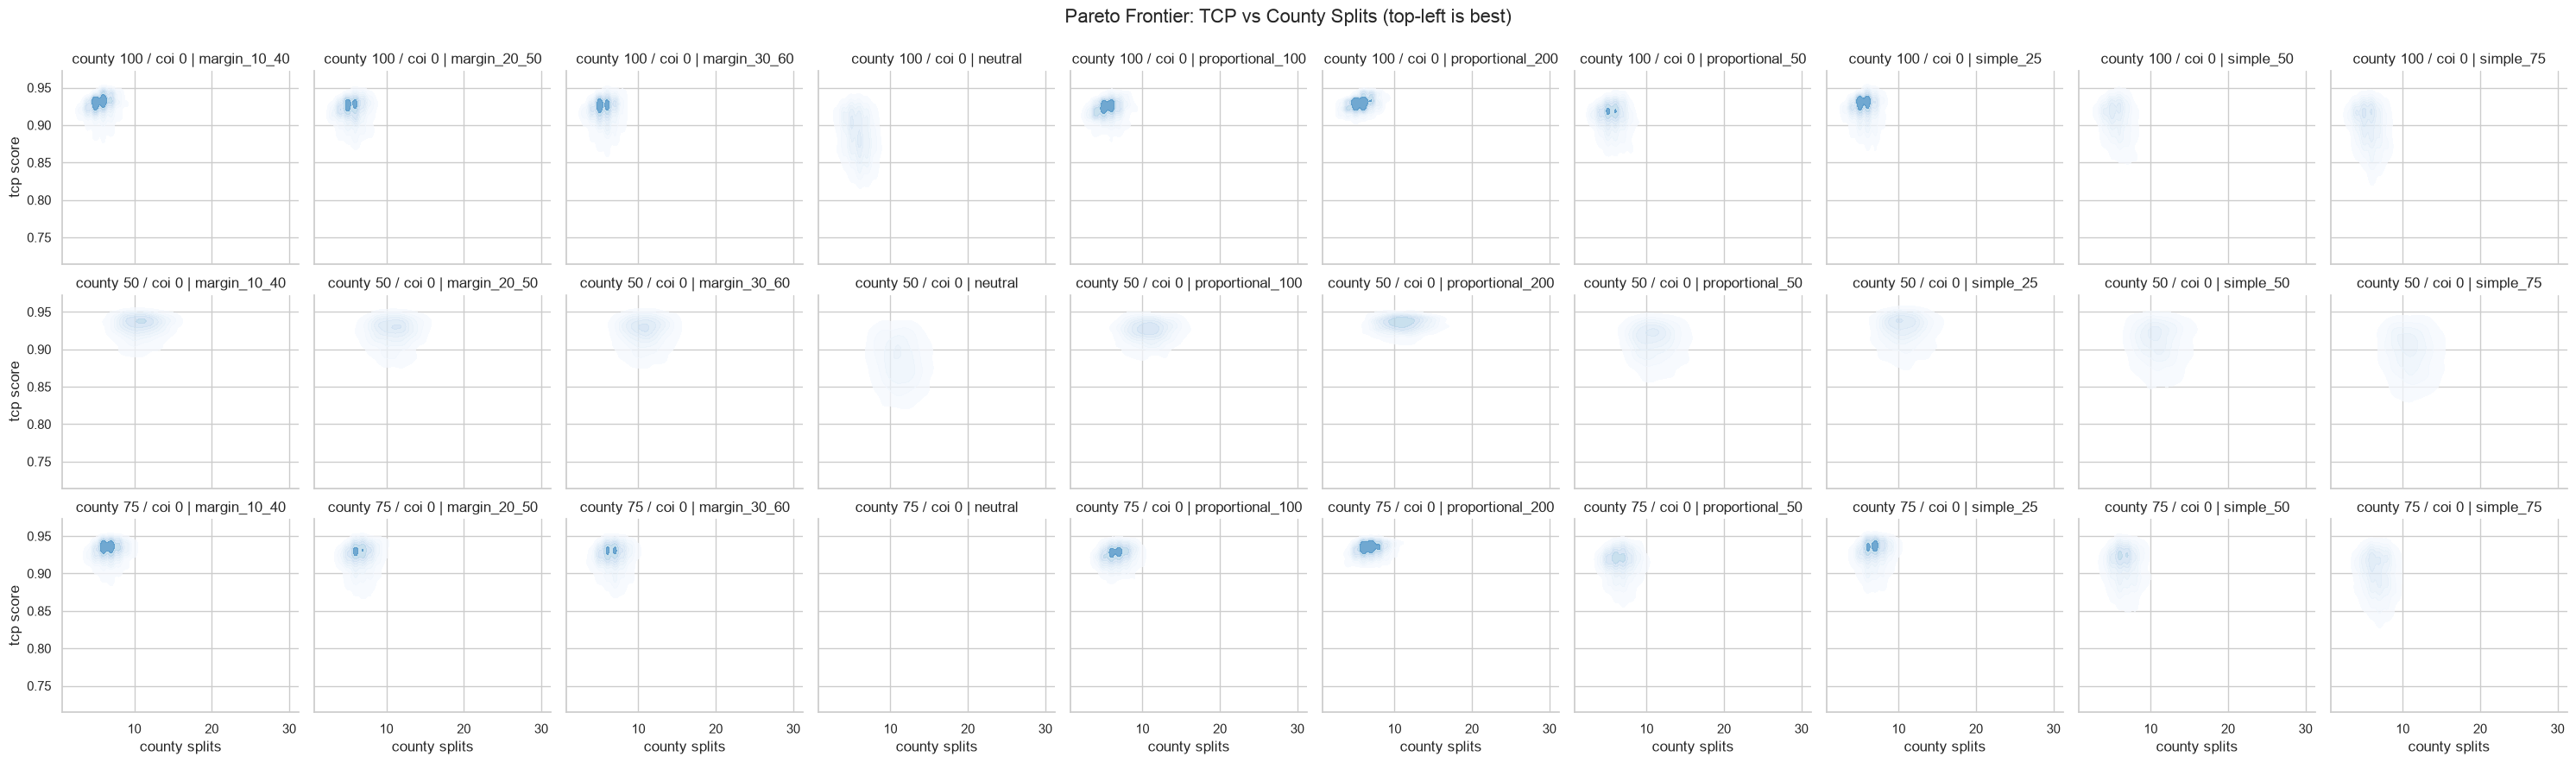

In [56]:
g = sns.displot(
    data=traces,
    x="county_split_count",
    y=TCP_COL,
    row="surcharge_label",
    col="strategy",
    kind="kde",
    fill=True,
    alpha=0.7,
    cmap="Blues",
    linewidths=0,
    levels=10,
    thresh=0.05,
    height=3,
    aspect=1
)

g.set_axis_labels("county splits", "tcp score")
g.set_titles(row_template="{row_name}", col_template="{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Pareto Frontier: TCP vs County Splits (top-left is best)", fontsize=16)
plt.show()

## TCP Over Steps

how does tcp evolve as the chain runs? smooth, stabilizing climbs suggest
realistic optimization. erratic swings suggest the acceptance function is
too loose or too tight.




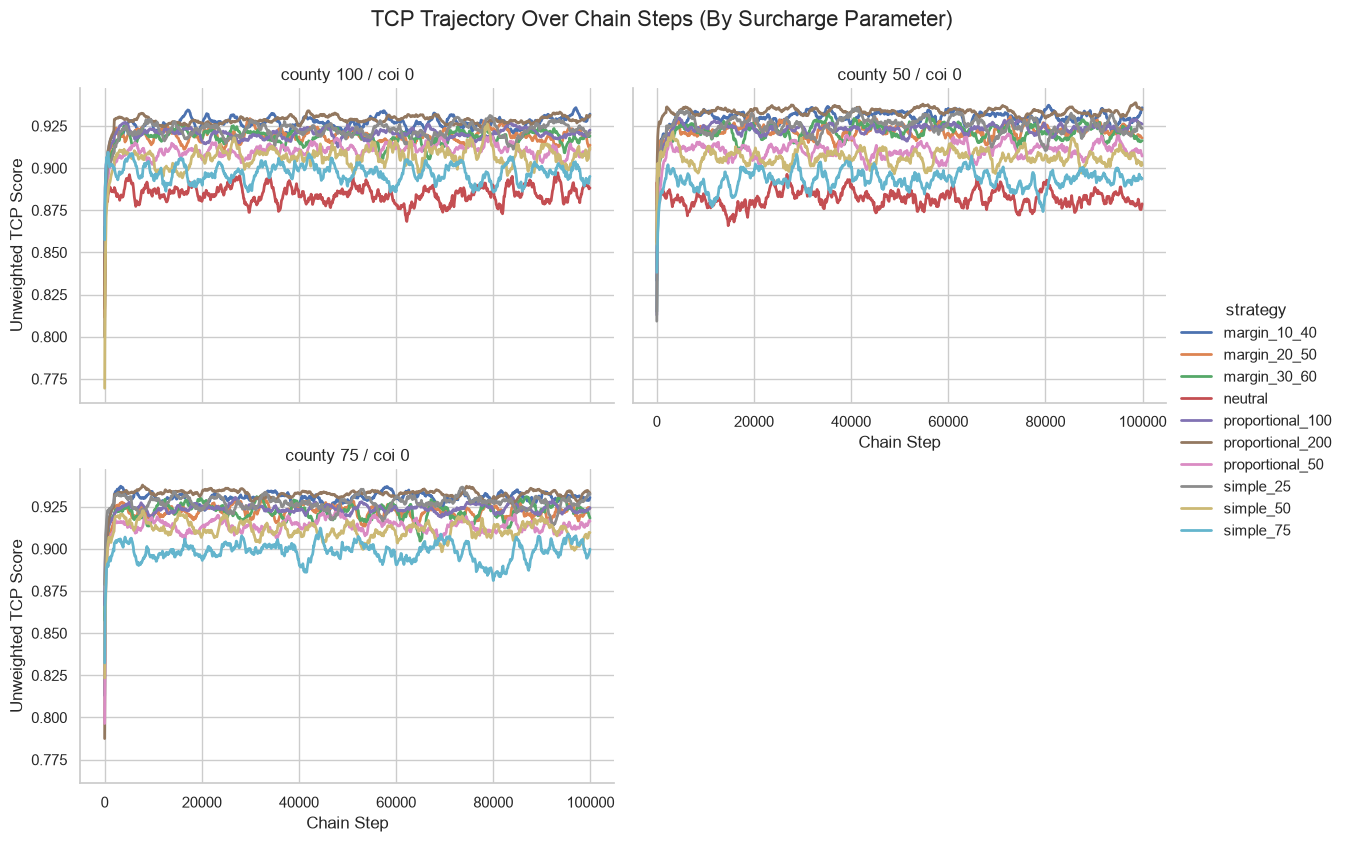

In [57]:
### tcp trajectory by strategy, faceted by surcharge config
grouped_traces = traces.groupby(['step', 'surcharge_label', 'strategy'], observed=True).mean(numeric_only=True).reset_index()
grouped_traces = grouped_traces.sort_values(['surcharge_label', 'strategy', 'step'])
grouped_traces[TCP_COL] = grouped_traces.groupby(['surcharge_label', 'strategy'], observed=True)[TCP_COL].transform(lambda x: x.rolling(20, min_periods=1).mean())
g = sns.relplot(
    data=grouped_traces,
    x='step',
    y=TCP_COL,
    hue='strategy',
    col='surcharge_label',
    col_wrap=2,
    kind='line',
    height=4,
    aspect=1.5,
    linewidth=2
)
g.set_axis_labels('Chain Step', 'Unweighted TCP Score')
g.set_titles('{col_name}')
g.fig.suptitle('TCP Trajectory Over Chain Steps (By Surcharge Parameter)', y=1.05, fontsize=16)
plt.show()


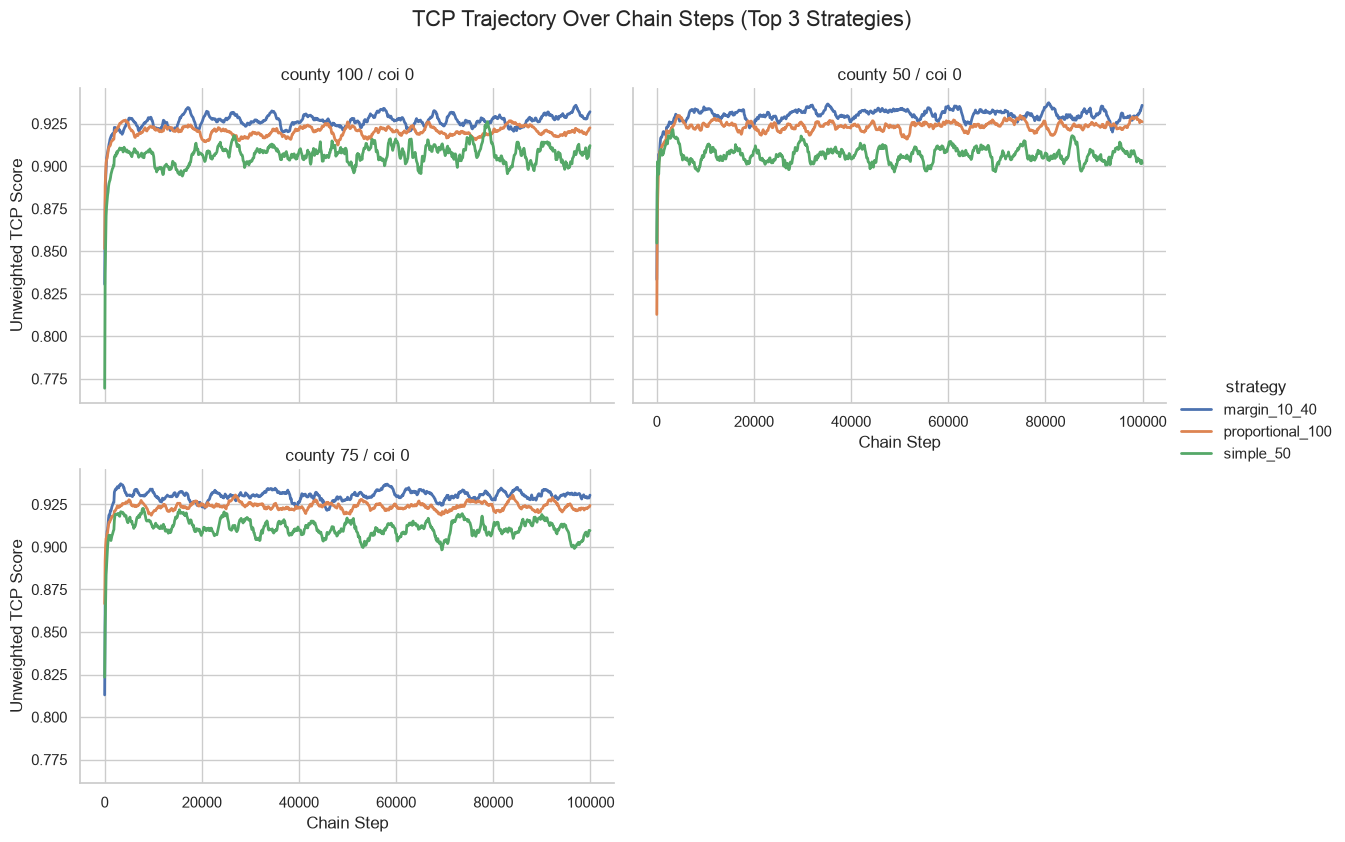

In [58]:
# filter based on the top 3 we think we like
top_strategies = ['margin_10_40', 'proportional_100', 'simple_50']
filtered_traces = traces[traces['strategy'].isin(top_strategies)].copy()
grouped_traces = filtered_traces.groupby(['step', 'surcharge_label', 'strategy'], observed=True).mean(numeric_only=True).reset_index()
grouped_traces = grouped_traces.sort_values(['surcharge_label', 'strategy', 'step'])
grouped_traces[TCP_COL] = grouped_traces.groupby(['surcharge_label', 'strategy'], observed=True)[TCP_COL].transform(lambda x: x.rolling(20, min_periods=1).mean())
# 3. Plot with thicker lines and a distinct color palette
g = sns.relplot(
    data=grouped_traces,
    x='step',
    y=TCP_COL,
    hue='strategy',
    col='surcharge_label',
    col_wrap=2,
    kind='line',
    height=4,
    aspect=1.5,
    linewidth=2,
)
g.set_axis_labels('Chain Step', 'Unweighted TCP Score')
g.set_titles('{col_name}')
g.fig.suptitle('TCP Trajectory Over Chain Steps (Top 3 Strategies)', y=1.05, fontsize=16)
plt.show()


## TCP Distributions By Strategy, Surcharge

we are looking for a strategy with a high median line and a fat upper body, indicating it consistently finds and preserves high-tcp maps.


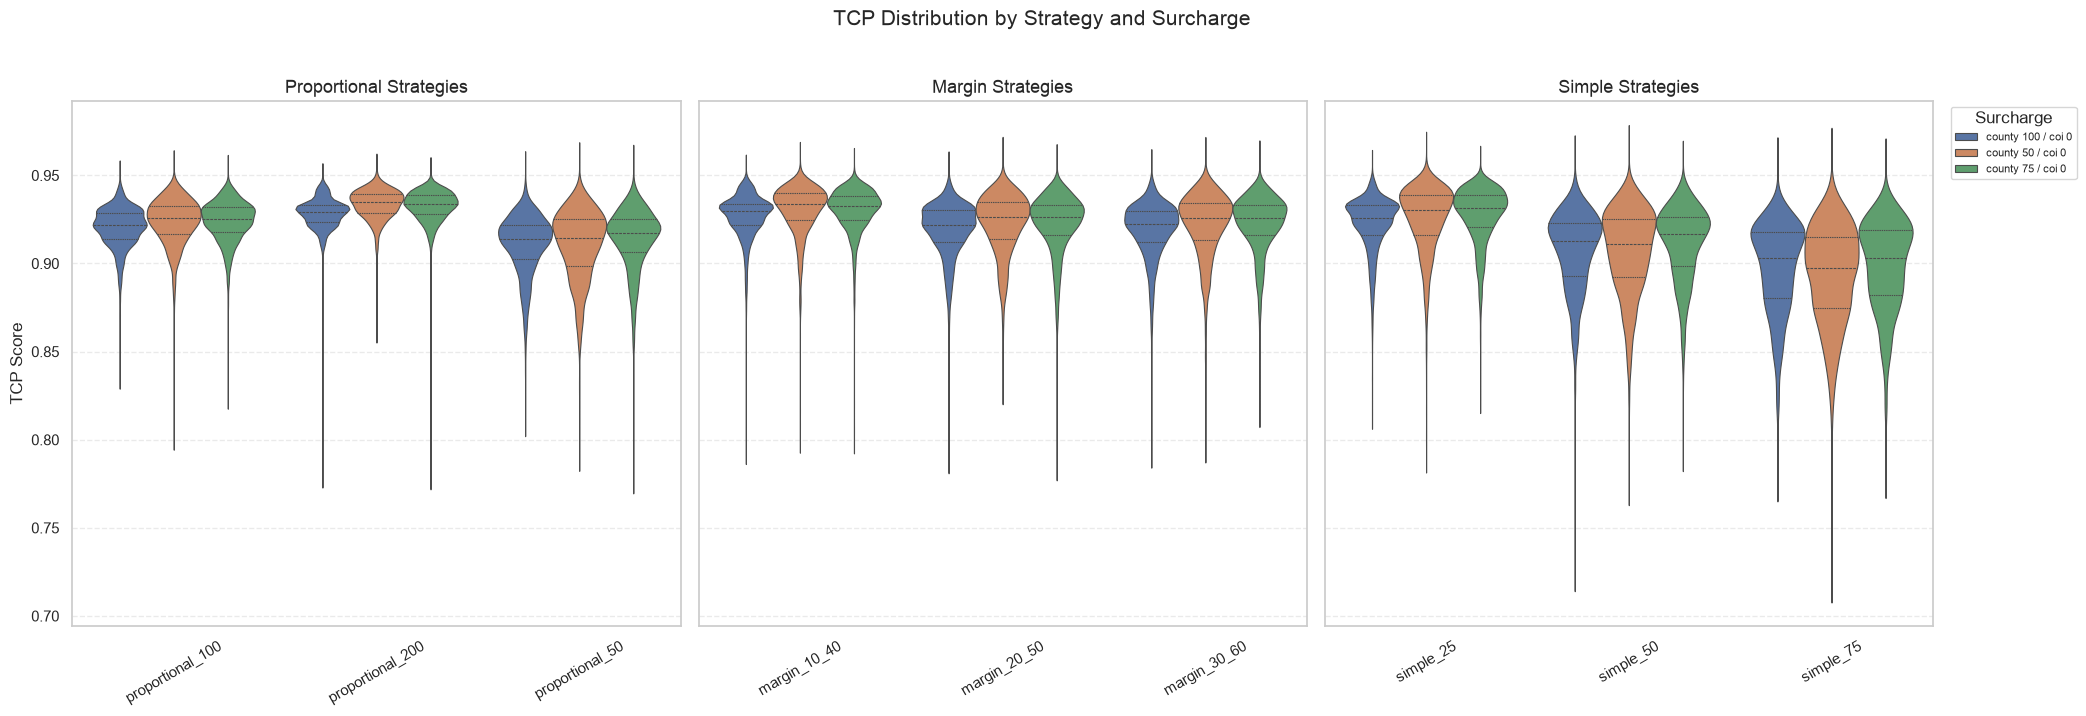

In [59]:
CLASS_ORDER = ['Proportional', 'Margin', 'Simple']
valid_classes = [c for c in CLASS_ORDER if c in traces['strategy_class'].unique()]

fig, axes = plt.subplots(1, len(valid_classes), figsize=(7 * len(valid_classes), 7), sharey=True)
if len(valid_classes) == 1:
    axes = [axes]

for i, s_class in enumerate(valid_classes):
    subset = traces[traces['strategy_class'] == s_class].copy()

    ### get strategies in this class, sorted
    strats_in_class = sorted(subset['strategy'].unique())
    subset['strategy'] = pd.Categorical(subset['strategy'], categories=strats_in_class, ordered=True)

    sns.violinplot(
        data=subset,
        x='strategy',
        y=TCP_COL,
        hue='surcharge_label',
        ax=axes[i],
        cut=5,
        inner='quartile',
        linewidth=0.8,
        density_norm='width',
    )

    axes[i].set_title(f'{s_class} Strategies', fontsize=13)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].grid(True, axis='y', linestyle='--', alpha=0.4)

    ### only show legend on last panel
    if i < len(valid_classes) - 1:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(title='Surcharge', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

axes[0].set_ylabel('TCP Score')
fig.suptitle('TCP Distribution by Strategy and Surcharge', fontsize=15, y=1.02)
fig.tight_layout()
plt.show()


## Summary Table
aggregated stats per strategy x surcharge combination.


In [60]:
### mean tcp by strategy x surcharge
pivot = master_df.pivot_table(
    index='strategy',
    columns='surcharge_label',
    values='mean_tcp',
    aggfunc='mean'
).round(4)

print('mean tcp by strategy x surcharge:')
display(pivot)

### same for county splits
pivot_splits = master_df.pivot_table(
    index='strategy',
    columns='surcharge_label',
    values='mean_county_splits',
    aggfunc='mean'
).round(2)

print('\nmean county splits by strategy x surcharge:')
display(pivot_splits)


mean tcp by strategy x surcharge:


surcharge_label,county 100 / coi 0,county 50 / coi 0,county 75 / coi 0
strategy,,,
margin_10_40,0.9266,0.9303,0.9302
margin_20_50,0.9191,0.9222,0.9226
margin_30_60,0.9187,0.9221,0.9224
neutral,0.8852,0.8814,NaN
proportional_100,0.9202,0.9239,0.9237
proportional_200,0.9286,0.9337,0.9326
proportional_50,0.9107,0.9114,0.9136
simple_25,0.9228,0.9251,0.9273
simple_50,0.9078,0.9076,0.9109



mean county splits by strategy x surcharge:


surcharge_label,county 100 / coi 0,county 50 / coi 0,county 75 / coi 0
strategy,,,
margin_10_40,5.67,10.84,6.77
margin_20_50,5.60,10.88,6.71
margin_30_60,5.60,10.81,6.71
neutral,5.83,11.17,NaN
proportional_100,5.54,10.89,6.66
proportional_200,5.65,11.01,6.81
proportional_50,5.58,10.92,6.64
simple_25,5.62,10.73,6.81
simple_50,5.65,10.92,6.60


## Check Mix

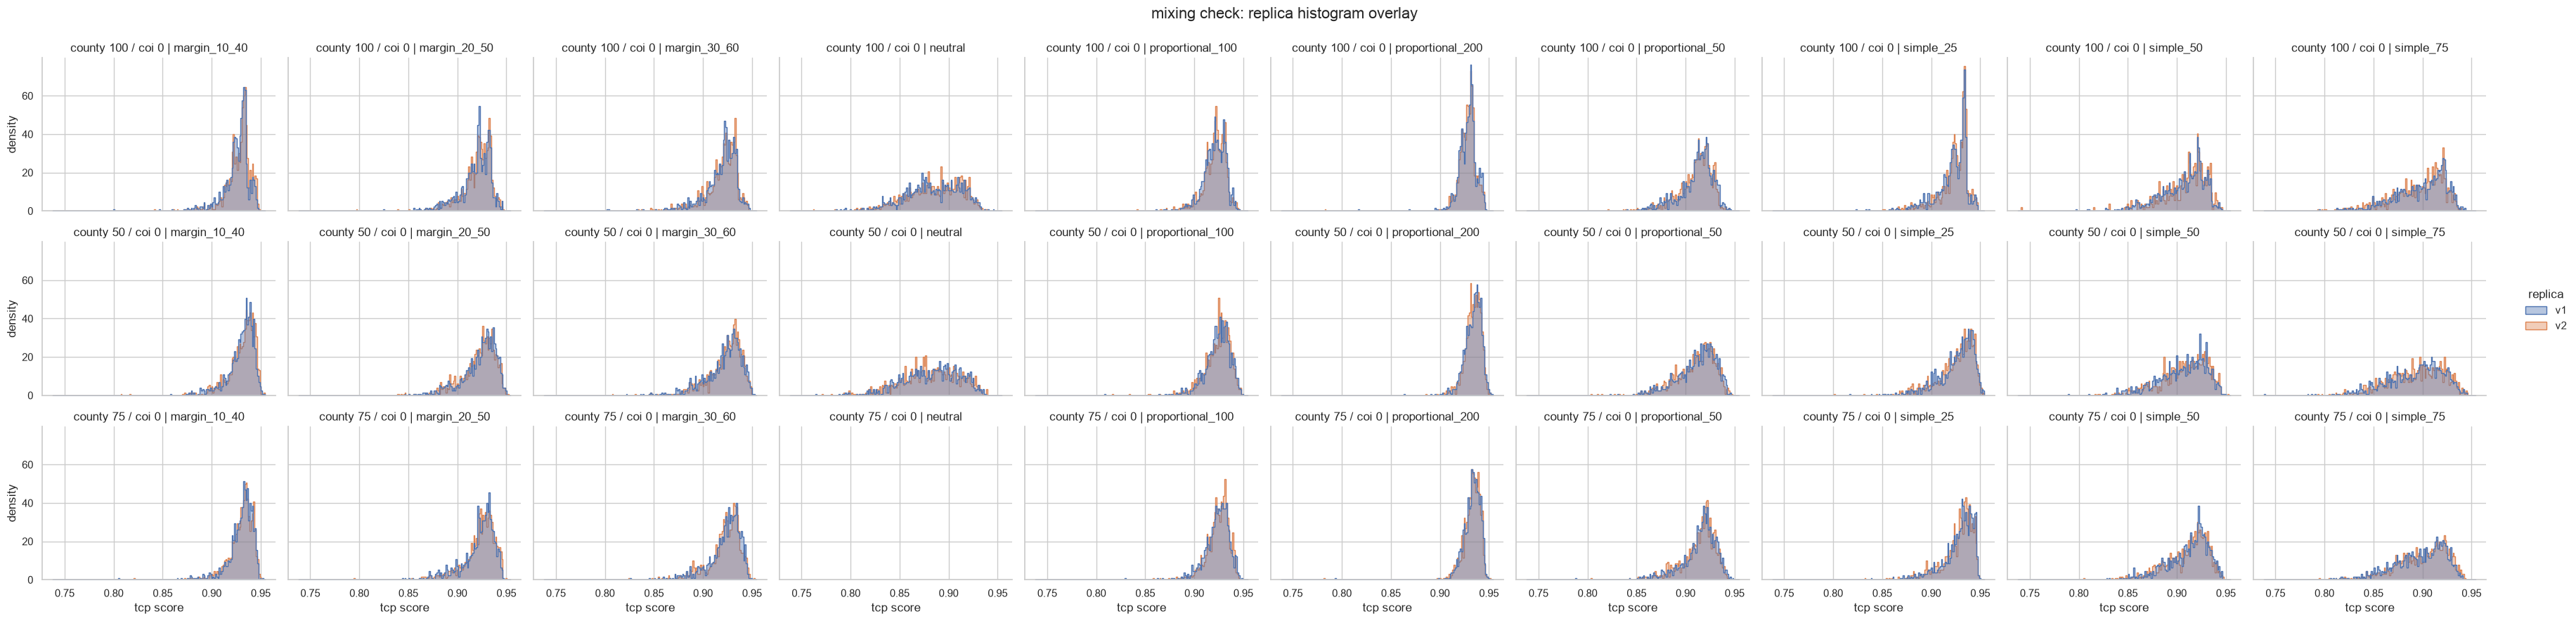

In [61]:
### overlay tcp histograms for v1 and v2
g = sns.displot(
    data=traces,
    x=TCP_COL,
    hue='replica',
    row='surcharge_label',
    col='strategy',
    kind='hist',
    element='step',
    stat='density',
    common_norm=False,
    height=3,
    aspect=1.2,
    alpha=0.4
)

g.set_axis_labels("tcp score", "density")
g.set_titles(row_template="{row_name}", col_template="{col_name}")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("mixing check: replica histogram overlay", fontsize=16)
plt.show()
